# Phase 3: Feature Engineering

## Objectives

In this phase, you will:

1. Create new features from existing ones
2. Combine related features to capture domain knowledge
3. Extract temporal and categorical interactions
4. Engineer features specific to house pricing
5. Perform feature selection to identify most important features
6. Create an enhanced dataset with improved predictive power

## Instructions

Feature engineering is where domain knowledge meets data science. Think creatively about what makes a house valuable.

---
## Task 1: Import Libraries and Load Preprocessed Data

In [2]:
# TODO: Import necessary libraries
# - pandas, numpy, matplotlib.pyplot, seaborn
# - from scipy import stats

# TODO: Set pandas display options
# - display.max_columns to None

# TODO: Print success message

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

print("Success!")


Success!


In [3]:
# TODO: Load preprocessed data from Phase 2
# - Read 'train_preprocessed.csv' and store in X
# - Read 'train_target.csv' and extract 'SalePrice' column into y
# - Read 'train_cleaned.csv' as df_original (for feature engineering with original values)

# TODO: Print shapes to verify data loaded correctly


X = pd.read_csv('train_preprocessed.csv')
y = pd.read_csv('train_target.csv')['SalePrice']
df_original = pd.read_csv('train_cleaned.csv')


print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("df_original Shape:", df_original.shape)

X Shape: (1460, 190)
y Shape: (1460,)
df_original Shape: (1460, 76)


---
## Task 2: Understanding Feature Engineering

Feature engineering involves creating new features that better represent the underlying problem. For house prices, consider:

### Common Feature Engineering Techniques:

1. **Aggregation Features**: Combine related features
   - Total square footage = basement + 1st floor + 2nd floor
   - Total bathrooms = full baths + 0.5 * half baths

2. **Ratio Features**: Create meaningful ratios
   - Living area to lot area ratio
   - Price per square foot indicators

3. **Temporal Features**: Extract time-based information
   - Age of house = Year sold - Year built
   - Years since remodel

4. **Boolean Features**: Create indicator variables
   - Has second floor (yes/no)
   - Has basement (yes/no)
   - Is remodeled (yes/no)

5. **Polynomial Features**: Interactions between features
   - OverallQual * GrLivArea
   - Quality squared

6. **Binning**: Group continuous variables
   - Age categories (new, medium, old)
   - Price ranges

---
## Task 3: Create Aggregation Features

Combine related features to create more meaningful variables.

**Note:** Work with the original cleaned data for feature creation, as it has interpretable values.

In [4]:
# TODO: Create a working copy from original cleaned data
# df_fe = df_original.copy()

# TODO: Print starting number of features


df_fe = df_original.copy()

print("Starting Number of Features:", df_fe.shape[1])


Starting Number of Features: 76


### Step 3.1: Total Square Footage Features

In [5]:
# TODO: Create total square footage feature
# Combine basement, 1st floor, and 2nd floor areas
# Example: df_fe['TotalSF'] = df_fe['TotalBsmtSF'] + df_fe['1stFlrSF'] + df_fe['2ndFlrSF']
# Check if columns exist before combining
# Print confirmation when created


sm = 0

if('TotalBsmtSF' in df_fe.columns):
    sm += df_fe['TotalBsmtSF']
else:
    print("Error: column 'TotalBsmtSF' is missing")

if('1stFlrSF' in df_fe.columns):
    sm += df_fe['1stFlrSF']
else:
    print("Error: column '1stFlrSF' is missing")

if('2ndFlrSF' in df_fe.columns):
    sm += df_fe['2ndFlrSF']
else:
    print("Error: column '2ndFlrSF' is missing")


df_fe['TotalSF'] = sm

print("Column df_fe['TotalSF'] created successfuly.")


Column df_fe['TotalSF'] created successfuly.


### Step 3.2: Bathroom Features

In [6]:
# TODO: Create total bathrooms feature
# Formula: FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
# Check if columns exist before combining


sm = 0

if('FullBath' in df_fe.columns):
    sm += df_fe['FullBath']
else:
    print("Error: column 'FullBath' is missing")

if('HalfBath' in df_fe.columns):
    sm +=  0.5 *  df_fe['HalfBath']
else:
    print("Error: column 'HalfBath' is missing")


if('BsmtFullBath' in df_fe.columns):
    sm +=  df_fe['BsmtFullBath']
else:
    print("Error: column 'BsmtFullBath' is missing")

if('BsmtHalfBath' in df_fe.columns):
    sm +=  0.5 *  df_fe['BsmtHalfBath']
else:
    print("Error: column 'BsmtHalfBath' is missing")


df_fe['TotalBaths'] = sm

print("Column df_fe['TotalBaths'] created successfully.")

Column df_fe['TotalBaths'] created successfully.


### Step 3.3: Porch and Outdoor Features

In [7]:
# TODO: Create total porch square footage
# Combine: OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch
# Check if columns exist before combining


sm = 0

if('OpenPorchSF' in df_fe.columns):
    sm += df_fe['OpenPorchSF']
else:
    print("Error: column 'OpenPorchSF' is missing")

if('EnclosedPorch' in df_fe.columns):
    sm += df_fe['EnclosedPorch']
else:
    print("Error: column 'EnclosedPorch' is missing")

if('3SsnPorch' in df_fe.columns):
    sm += df_fe['3SsnPorch']
else:
    print("Error: column '3SsnPorch' is missing")

if('ScreenPorch' in df_fe.columns):
    sm += df_fe['ScreenPorch']
else:
    print("Error: column 'ScreenPorch' is missing")

df_fe['TotalPorchSF'] = sm

print("Column df_fe['TotalPorchSF'] created successfully.")

Column df_fe['TotalPorchSF'] created successfully.


### Step 3.4: Your Custom Aggregation Features

Think about other meaningful combinations. What other groups of features make sense to combine?

In [8]:
# Your creative aggregation features here
# Examples:
# - Total rooms above ground
# - Total quality score (combine various quality ratings)
# - Total finished area vs unfinished area

if ('GrLivArea' in df_fe.columns and 'TotalBsmtSF' in df_fe.columns and 'BsmtUnfSF' in df_fe.columns):
    finished_area = df_fe['GrLivArea'] + (df_fe['TotalBsmtSF'] - df_fe['BsmtUnfSF'])
    unfinished_area = df_fe['BsmtUnfSF']
    df_fe['FinishedToUnfinishedRatio'] = finished_area / (unfinished_area + 1)
    print("Column df_fe['FinishedToUnfinishedRatio'] created successfully.")
else:
    print("Error: Missing columns for FinishedToUnfinishedRatio")


Column df_fe['FinishedToUnfinishedRatio'] created successfully.


---
## Task 4: Create Ratio and Proportion Features

Ratios can capture important relationships between features.

In [9]:
# Example: Living area to lot area ratio
# if 'GrLivArea' in df_fe.columns and 'LotArea' in df_fe.columns:
#     df_fe['LivingArea_to_LotArea'] = df_fe['GrLivArea'] / df_fe['LotArea']
#     print("Created: LivingArea_to_LotArea")


if ('GrLivArea' in df_fe.columns and 'LotArea' in df_fe.columns):
    df_fe['LivingArea_to_LotArea'] = df_fe['GrLivArea'] / df_fe['LotArea']
    print("Created: LivingArea_to_LotArea")
else:
    print("Error: Missing columns for LivingArea_to_LotArea")

# Your ratio features here
# Ideas:
# - Basement ratio (basement area / total area)
# - Land slope to lot area
# - Garage area to living area


if ('TotalBsmtSF' in df_fe.columns and 'TotalSF' in df_fe.columns):
    df_fe['BasementRatio'] = df_fe['TotalBsmtSF'] / df_fe['TotalSF']
    print("Created: BasementRatio")
else:
    print("Error: Missing columns for BasementRatio")


Created: LivingArea_to_LotArea
Created: BasementRatio


---
## Task 5: Create Temporal Features

Extract time-related features that might affect house prices.

In [10]:
# Example: House age at time of sale
# if 'YrSold' in df_fe.columns and 'YearBuilt' in df_fe.columns:
#     df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
#     print("Created: HouseAge")

if ('YrSold' in df_fe.columns and 'YearBuilt' in df_fe.columns):
    df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
    print("Column df_fe['HouseAge'] created successfully.")
else:
    print("Error: Missing columns for HouseAge")


# Your temporal features here
# Ideas:
# - Years since remodel
# - Was remodeled (boolean)
# - Garage age
# - Is newly built (within 5 years)


if ('YrSold' in df_fe.columns and 'YearBuilt' in df_fe.columns):
    df_fe['IsNewHouse'] = (df_fe['YrSold'] - df_fe['YearBuilt'] <= 3).astype(int)
    print("Column df_fe['IsNewHouse'] created successfully.")
else:
    print("Error: Missing columns for IsNewHouse")

Column df_fe['HouseAge'] created successfully.
Column df_fe['IsNewHouse'] created successfully.


---
## Task 6: Create Boolean/Indicator Features

Binary features can be very informative.

In [11]:
# Example: Has second floor
# if '2ndFlrSF' in df_fe.columns:
#     df_fe['HasSecondFloor'] = (df_fe['2ndFlrSF'] > 0).astype(int)
#     print("Created: HasSecondFloor")


if ('2ndFlrSF' in df_fe.columns):
    df_fe['HasSecondFloor'] = (df_fe['2ndFlrSF'] > 0).astype(int)
    print("Column df_fe['HasSecondFloor'] created successfully.")
else:
    print("Error: Missing columns for HasSecondFloor")

# Your boolean features here
# Ideas:
# - Has basement
# - Has garage
# - Has fireplace
# - Has pool
# - Has porch
# - Is remodeled (YearRemodAdd != YearBuilt)

if ('GarageArea' in df_fe.columns):
    df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)
    print("Column df_fe['HasGarage'] created successfully.")
else:
    print("Error: Missing columns for HasGarage")


Column df_fe['HasSecondFloor'] created successfully.
Column df_fe['HasGarage'] created successfully.


---
## Task 7: Create Interaction Features

Sometimes the interaction between features is more important than individual features.

In [12]:
# Example: Overall quality * living area
# High quality homes with large area are especially valuable
# if 'OverallQual' in df_fe.columns and 'GrLivArea' in df_fe.columns:
#     df_fe['Quality_x_Area'] = df_fe['OverallQual'] * df_fe['GrLivArea']
#     print("Created: Quality_x_Area")


if ('OverallQual' in df_fe.columns and 'GrLivArea' in df_fe.columns):
    df_fe['Quality_x_Area'] = df_fe['OverallQual'] * df_fe['GrLivArea']
    print("Created: Quality_x_Area")
else:
    print("Error: Missing columns for Quality_x_Area")


# Your interaction features here
# Ideas:
# - Quality * condition
# - Neighborhood quality indicator * area
# - Bathrooms * bedrooms

if ('TotalBaths' in df_fe.columns and 'BedroomAbvGr' in df_fe.columns):
    df_fe['Bath_x_Bed'] = df_fe['TotalBaths'] * df_fe['BedroomAbvGr']
    print("Column df_fe['Bath_x_Bed'] created successfully.")
else:
    print("Error: Missing columns for Bath_x_Bed")


Created: Quality_x_Area
Column df_fe['Bath_x_Bed'] created successfully.


---
## Task 8: Create Polynomial Features (Optional)

Squared or higher-order terms can capture non-linear relationships.

In [13]:
# Example: Quality squared
# if 'OverallQual' in df_fe.columns:
#     df_fe['OverallQual_Squared'] = df_fe['OverallQual'] ** 2
#     print("Created: OverallQual_Squared")

if ('OverallQual' in df_fe.columns):
    df_fe['OverallQual_Squared'] = df_fe['OverallQual'] ** 2
    print("Created: OverallQual_Squared")


# Your polynomial features here (be selective, don't overdo it)
# Usually apply to features with strong correlations to target


if ('GrLivArea' in df_fe.columns):
    df_fe['GrLivArea_Squared'] = df_fe['GrLivArea'] ** 2
    print("Created: GrLivArea_Squared")

Created: OverallQual_Squared
Created: GrLivArea_Squared


---
## Task 9: Feature Summary and Analysis

Review all the features you've created.

In [14]:
# TODO: Identify new features created
# - Compare columns in df_fe vs df_original
# - Use list comprehension to find new columns
# - Store in 'new_features' variable

# TODO: Print feature counts
# - Original feature count (from df_original.columns)
# - New features created (length of new_features list)
# - Total features (from df_fe.columns)

# TODO: Print list of all new features with numbering


new_features = [col for col in df_fe.columns if col not in df_original.columns]

print("Original feature count:", len(df_original.columns))
print("New features created:", len(new_features))
print("Total Features:", len(df_fe.columns))

for i , feature in enumerate(new_features):
    print(i + 1, feature)

Original feature count: 76
New features created: 14
Total Features: 90
1 TotalSF
2 TotalBaths
3 TotalPorchSF
4 FinishedToUnfinishedRatio
5 LivingArea_to_LotArea
6 BasementRatio
7 HouseAge
8 IsNewHouse
9 HasSecondFloor
10 HasGarage
11 Quality_x_Area
12 Bath_x_Bed
13 OverallQual_Squared
14 GrLivArea_Squared


In [15]:
# TODO: Display statistics of new features
# - Check if new_features list is not empty
# - Use df_fe[new_features].describe() to show statistics
# - Print the descriptive statistics


if(len(new_features) > 0):
   print( df_fe[new_features].describe())
else:
   print("new_features list is emppty.")

            TotalSF   TotalBaths  TotalPorchSF  FinishedToUnfinishedRatio  \
count   1460.000000  1460.000000   1460.000000                1460.000000   
mean    2567.048630     2.210616     87.084932                 162.847430   
std      821.714421     0.785399    105.190364                 569.372417   
min      334.000000     1.000000      0.000000                   0.998081   
25%     2009.500000     2.000000      0.000000                   1.997257   
50%     2474.000000     2.000000     48.000000                   4.228407   
75%     3004.000000     2.500000    136.000000                   9.448611   
max    11752.000000     6.000000   1027.000000                4463.000000   

       LivingArea_to_LotArea  BasementRatio     HouseAge   IsNewHouse  \
count            1460.000000    1460.000000  1460.000000  1460.000000   
mean                0.180590       0.407686    36.547945     0.163699   
std                 0.111914       0.107678    30.250152     0.370129   
min           

---
## Task 10: Analyze Feature Correlations with Target

Evaluate which features (old and new) correlate strongest with SalePrice.

In [16]:
# TODO: Add target variable for correlation analysis
# - Add 'SalePrice' column from df_original to df_fe

df_fe['SalePrice'] = df_original['SalePrice']

# TODO: Calculate correlations with target
# - Select only numerical columns using select_dtypes
# - Calculate correlation matrix using .corr()
# - Extract 'SalePrice' column and sort in descending order
# - Store in 'correlations' variable

correlations = df_fe.select_dtypes(include=['number']).corr()['SalePrice'].sort_values(ascending = False)

# TODO: Print top 20 features most correlated with SalePrice
# TODO: Print bottom 10 features (negative or weak correlation)

print("Top 20 features most correlated with SalePrice:")
print(correlations.head(20))

correlations_asc = df_fe.select_dtypes(include=['number']).corr()['SalePrice'].sort_values(ascending = True)

print()

print("Bottom 10 features (negative or weak correlation:")
print(correlations_asc.head(10))



Top 20 features most correlated with SalePrice:
SalePrice              1.000000
Quality_x_Area         0.832057
OverallQual_Squared    0.817168
OverallQual            0.790982
TotalSF                0.782260
GrLivArea              0.708624
GrLivArea_Squared      0.652267
GarageCars             0.640409
TotalBaths             0.631731
GarageArea             0.623431
TotalBsmtSF            0.613581
1stFlrSF               0.605852
FullBath               0.560664
TotRmsAbvGrd           0.533723
Bath_x_Bed             0.524153
YearBuilt              0.522897
YearRemodAdd           0.507101
MasVnrArea             0.472614
Fireplaces             0.466929
IsNewHouse             0.423936
Name: SalePrice, dtype: float64

Bottom 10 features (negative or weak correlation:
HouseAge                    -0.523350
KitchenAbvGr                -0.135907
EnclosedPorch               -0.128578
FinishedToUnfinishedRatio   -0.090786
MSSubClass                  -0.084284
OverallCond                 -0.077856
Y

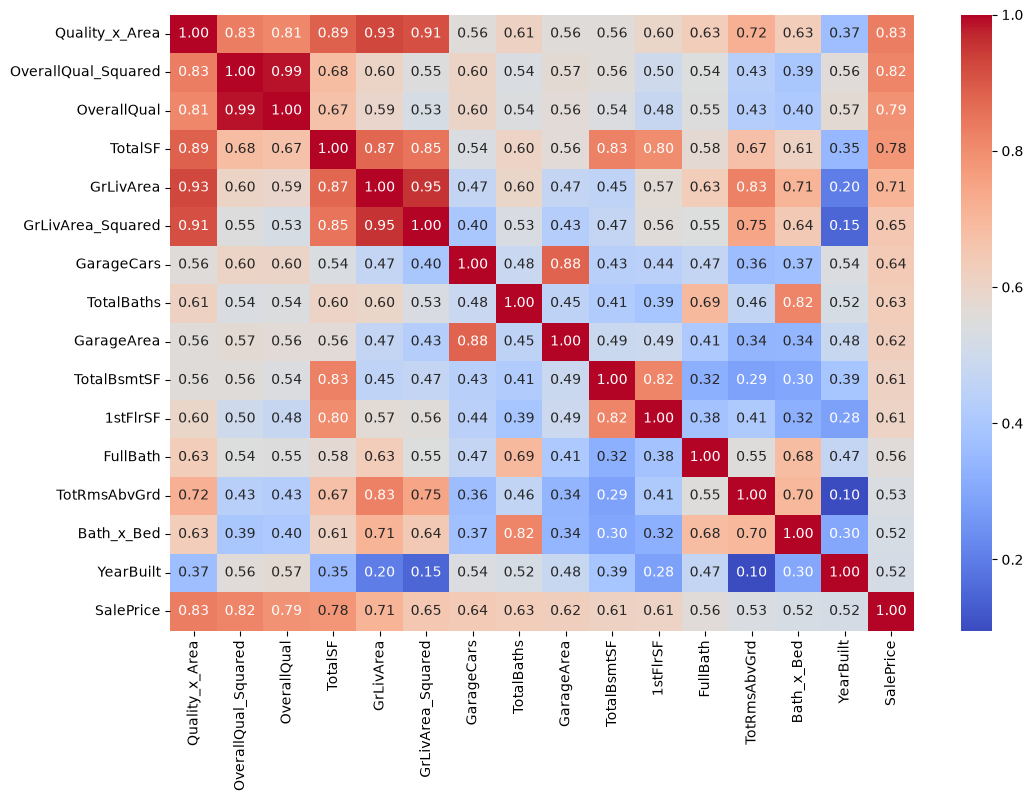

In [17]:
# TODO: Visualize top correlations
# - Get top 15 features from correlations
# - Remove 'SalePrice' itself from the list
# - Create correlation matrix of top features with SalePrice
# - Create heatmap using seaborn (figsize=(12, 8))
# - Use coolwarm colormap with annotations
# - Add title and display the plot

top_15 = correlations.head(16).index.drop('SalePrice')

corr_matrix = df_fe[top_15.to_list() + ['SalePrice']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt='.2f')
plt.show()


### Analysis: Which New Features are Most Valuable?

Identify which of your newly created features show strong correlation with SalePrice.

Quality_x_Area               0.832057
OverallQual_Squared          0.817168
TotalSF                      0.782260
GrLivArea_Squared            0.652267
TotalBaths                   0.631731
Bath_x_Bed                   0.524153
IsNewHouse                   0.423936
HasGarage                    0.236832
TotalPorchSF                 0.195739
HasSecondFloor               0.137656
BasementRatio                0.047582
LivingArea_to_LotArea       -0.002416
FinishedToUnfinishedRatio   -0.090786
HouseAge                    -0.523350
Name: SalePrice, dtype: float64


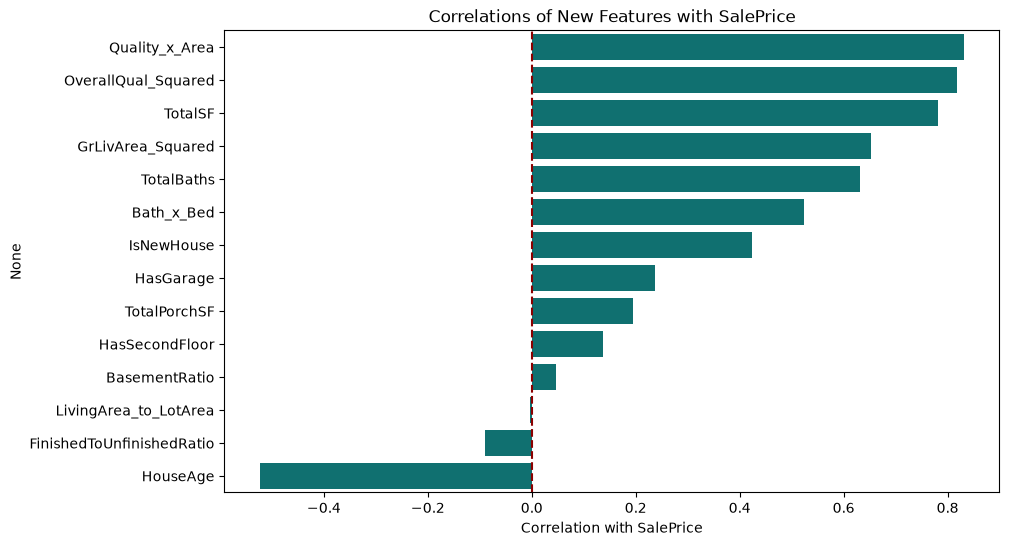

In [18]:
# TODO: Analyze new features specifically
# - Check if new_features list is not empty
# - Get correlations for only new features from correlations series
# - Sort values in descending order
# - Print correlations of new features with SalePrice

# TODO: Visualize new feature correlations
# - Create horizontal bar plot (figsize=(10, 6))
# - Use color='teal'
# - Add xlabel, title
# - Add vertical line at x=0 to show positive/negative correlations
# - Display the plot


if(len(new_features) > 0):
    new_corr = correlations[new_features].sort_values(ascending=False)
    print(new_corr)

    plt.figure(figsize=(10, 6))
    sns.barplot(x = new_corr.values, y = new_corr.index, color='teal')
    plt.xlabel('Correlation with SalePrice')
    plt.title('Correlations of New Features with SalePrice')
    plt.axvline(x = 0, color = 'darkred', linestyle = '--')
    plt.show()
else:
    print("new_features list is empty")

---
## Task 11: Feature Selection (Optional)

Consider removing features with:
- Very low correlation with target (< 0.05)
- High correlation with other features (multicollinearity)
- Little variance

In [19]:
# TODO: Identify low-correlation features
# - Set threshold (e.g., 0.05)
# - Filter features with absolute correlation < threshold
# - Remove 'SalePrice' if present in the list
# - Print count of low-correlation features
# - Print first 10 features from the list

# TODO: Document your decision
# - Should these features be kept or removed?
# - Write your reasoning as a comment

#   I don't think our dataset is that big, so it's not worth touching such small differences


In [ ]:
# TODO: Check for multicollinearity among top features
# - Get top 20 features from correlations
# - Remove 'SalePrice' if present
# - Create correlation matrix for these features

# TODO: Find highly correlated pairs (>0.8)
# - Loop through correlation matrix
# - Find pairs with |correlation| > 0.8
# - Store pairs with their correlation values
# - Print results

# High correlation between features might indicate redundancy
# Consider removing one from highly correlated pairs


top_20 = correlations.head(21).index.drop('SalePrice')
corr_matrix_top20 = df_fe[top_20].corr()

high_corr_pairs = []

for i in range(len(corr_matrix_top20.columns)):
    for j in range(i + 1, len(corr_matrix_top20.columns) ):
        feature1 = top_20[i]
        feature2 = top_20[j]
        value = corr_matrix_top20.loc[feature1, feature2]

        if(abs(value) > 0.8):
            high_corr_pairs.append((feature1, feature2, value))


for f1, f2, val in high_corr_pairs:
    print(f1, f2, val)



Quality_x_Area OverallQual_Squared 0.8305853675649765
Quality_x_Area OverallQual 0.8101651994829744
Quality_x_Area TotalSF 0.8861375000859266
Quality_x_Area GrLivArea 0.9286576400677298
Quality_x_Area GrLivArea_Squared 0.9128086680122576
OverallQual_Squared OverallQual 0.9877191713485958
TotalSF GrLivArea 0.8743728652580668
TotalSF GrLivArea_Squared 0.8504995913900554
TotalSF TotalBsmtSF 0.8267423791406745
TotalSF 1stFlrSF 0.8003499326002391
GrLivArea GrLivArea_Squared 0.954146740796346
GrLivArea TotRmsAbvGrd 0.8254893743088425
GarageCars GarageArea 0.882475414281462
TotalBaths Bath_x_Bed 0.8191847452428798
TotalBsmtSF 1stFlrSF 0.8195299750050339


---
## Task 12: Apply Feature Engineering to Test Set

Create the exact same features for the test dataset.

In [ ]:
# Load test data (you should have a cleaned version from Phase 1)
# test_df = pd.read_csv('test_cleaned.csv')

# Apply ALL the same feature engineering steps
# This is critical for model predictions later

# Your code here

test_test = pd.read_csv('test_cleaned.csv')
test_fe = test_test.copy()

sm = 0
if ('TotalBsmtSF' in test_fe.columns): 
    sm += test_fe['TotalBsmtSF']
if ('1stFlrSF' in test_fe.columns): 
    sm += test_fe['1stFlrSF']
if ('2ndFlrSF' in test_fe.columns): 
    sm += test_fe['2ndFlrSF']
test_fe['TotalSF'] = sm
print("Created: TotalSF")


sm = 0
if ('FullBath' in test_fe.columns): 
    sm += test_fe['FullBath']
if ('HalfBath' in test_fe.columns): 
    sm += 0.5 * test_fe['HalfBath']
if ('BsmtFullBath' in test_fe.columns): 
    sm += test_fe['BsmtFullBath']
if ('BsmtHalfBath' in test_fe.columns): 
    sm += 0.5 * test_fe['BsmtHalfBath']
test_fe['TotalBaths'] = sm
print("Created: TotalBaths")


sm = 0
if ('OpenPorchSF' in test_fe.columns): 
    sm += test_fe['OpenPorchSF']
if ('EnclosedPorch' in test_fe.columns): 
    sm += test_fe['EnclosedPorch']
if ('3SsnPorch' in test_fe.columns): 
    sm += test_fe['3SsnPorch']
if ('ScreenPorch' in test_fe.columns): 
    sm += test_fe['ScreenPorch']
test_fe['TotalPorchSF'] = sm
print("Created: TotalPorchSF")



if ('GrLivArea' in test_fe.columns and 'TotalBsmtSF' in test_fe.columns and 'BsmtUnfSF' in test_fe.columns):
    finished_area = test_fe['GrLivArea'] + (test_fe['TotalBsmtSF'] - test_fe['BsmtUnfSF'])
    unfinished_area = test_fe['BsmtUnfSF']
    test_fe['FinishedToUnfinishedRatio'] = finished_area / (unfinished_area + 1)
    print("Created: FinishedToUnfinishedRatio")


if ('GrLivArea' in test_fe.columns and 'LotArea' in test_fe.columns):
    test_fe['LivingArea_to_LotArea'] = test_fe['GrLivArea'] / test_fe['LotArea']
    print("Created: LivingArea_to_LotArea")


if ('TotalBsmtSF' in test_fe.columns and 'TotalSF' in test_fe.columns):
    test_fe['BasementRatio'] = test_fe['TotalBsmtSF'] / test_fe['TotalSF']
    print("Created: BasementRatio")


if ('YrSold' in test_fe.columns and 'YearBuilt' in test_fe.columns):
    test_fe['HouseAge'] = test_fe['YrSold'] - test_fe['YearBuilt']
    print("Created: HouseAge")
    
    test_fe['IsNewHouse'] = (test_fe['YrSold'] - test_fe['YearBuilt'] <= 3).astype(int)
    print("Created: IsNewHouse")


if ('2ndFlrSF' in test_fe.columns):
    test_fe['HasSecondFloor'] = (test_fe['2ndFlrSF'] > 0).astype(int)
    print("Created: HasSecondFloor")


if ('GarageArea' in test_fe.columns):
    test_fe['HasGarage'] = (test_fe['GarageArea'] > 0).astype(int)
    print("Created: HasGarage")


if ('OverallQual' in test_fe.columns and 'GrLivArea' in test_fe.columns):
    test_fe['Quality_x_Area'] = test_fe['OverallQual'] * test_fe['GrLivArea']
    print("Created: Quality_x_Area")


if ('TotalBaths' in test_fe.columns and 'BedroomAbvGr' in test_fe.columns):
    test_fe['Bath_x_Bed'] = test_fe['TotalBaths'] * test_fe['BedroomAbvGr']
    print("Created: Bath_x_Bed")


if ('OverallQual' in test_fe.columns):
    test_fe['OverallQual_Squared'] = test_fe['OverallQual'] ** 2
    print("Created: OverallQual_Squared")
    

if ('GrLivArea' in test_fe.columns):
    test_fe['GrLivArea_Squared'] = test_fe['GrLivArea'] ** 2
    print("Created: GrLivArea_Squared")


---
## Task 13: Final Feature Engineering Summary

Document all transformations for reproducibility.

In [29]:
# TODO: Prepare for saving
# - Keep 'SalePrice' column in df_fe (needed for model training in Phase 5)
# - df_fe_final = df_fe (with SalePrice included)

df_fe_final = df_fe

# TODO: Print Feature Engineering Summary
# - Original feature count (subtract 1 for SalePrice)
# - New features created (length of new_features)
# - Total features in final dataset
# - Total samples (rows)
# - Count of missing values

print("Original feature count:",len(df_fe_final.columns) - len(new_features) - 1)
print("New features created:", len(new_features))
print("Total features in dataset:", len(df_fe_final.columns))
print("Total samples", len(df_fe_final))
print("Count of missing values:", df_fe_final.isnull().sum().sum())


Original feature count: 75
New features created: 14
Total features in dataset: 90
Total samples 1460
Count of missing values: 1201


In [31]:
# TODO: Save feature-engineered dataset
# - Save df_fe_final to 'train_feature_engineered.csv'
# - Use index=False parameter
# - Print confirmation message

# TODO: Save list of new features for documentation
# - Open file 'new_features_list.txt' for writing
# - Write header "New Features Created:"
# - Write separator line
# - Write each feature name with numbering
# - Print confirmation message


df_fe_final.to_csv('train_feature_engineered.csv', index=False)
print("Saved df_fe_final to 'train_feature_engineered.csv'")


with open('new_features_list.txt', 'w') as f:
    f.write("New Features Created:")
    print()
    f.write("--------------------------------------")
    print()
    for i, feature in enumerate(new_features):
        f.write(f"{i + 1}. {feature}\n")

print("Saved new features list to 'new_features_list.txt'")

Saved df_fe_final to 'train_feature_engineered.csv'


Saved new features list to 'new_features_list.txt'


---
## Summary and Reflection

### What You Accomplished:

1. Created aggregation features by combining related variables
2. Developed ratio and proportion features
3. Extracted temporal features (age, renovation status)
4. Created boolean indicator features
5. Engineered interaction and polynomial features
6. Analyzed correlations of new features with target
7. Assessed feature importance and multicollinearity
8. Applied same transformations to test data

### Key Questions for Reflection:

1. How many new features did you create? 14
2. Which new features have the highest correlation with SalePrice?  "Quality_x_Area", "OverallQual_Squared"
3. Did any of your engineered features outperform existing features? Yes, combined features like Quality_x_Area captured non-linear relationships better than raw variables.
4. How did you handle multicollinearity among features? By combining redundant columns into single totals (like TotalSF) and relying on future regularization.
5. What domain knowledge about real estate did you apply? Calculated total living space, house age, and combined material quality with size

### Feature Engineering Best Practices:

- **Domain knowledge is key**: Understand what makes houses valuable
- **Keep it interpretable**: Features should make logical sense
- **Avoid data leakage**: Don't use future information
- **Document everything**: Track all transformations for reproducibility
- **Balance quantity with quality**: More features isn't always better

### Next Steps:

Proceed to **Phase 4: Exploratory Data Analysis** where you will:
- Visualize distributions and relationships
- Identify patterns in the data
- Validate your feature engineering decisions
- Prepare final insights before modeling